So far the exemplary digits approach did not yield viable outcomes. The appraches tried were:  
1-Fully connected network [784, 784, 784, 10].  
2-Ensemble of fully connected networks all [784, 784, 784, 10].  
3-Ensemble of fully connected networks of varying architectures.  
4-Ensemble of fully connected, cnn, bidirectional rnn, rows GRU, and columns GRU.  
5-Same ensemble as 4 but with normalization of logits.  

This notebook is to try one more method. Adding one output for not-a-digit and augmenting the dataset.

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import torch
import random
import torch.nn as nn
import torch.optim as optim

In [38]:
# creating a random affine transform and 50% chance of noise random or black and white
class TransformedMnist(Dataset):
  def __init__(self, base_dataset, noise_dataset):
    self.base_dataset = base_dataset
    self.noise_dataset = noise_dataset
    self.affine_transform = transforms.RandomAffine(
        degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)
    )
    self.to_tensor = transforms.ToTensor()

  def __len__(self):
    return len(self.base_dataset)

  def __getitem__(self, idx):
    img, label = self.base_dataset[idx]

    r = random.random()
    if r < 0.125:
      img = torch.rand(1, 28, 28)          # Uniform noise
      label = 10                           # New label for noise
    elif r < 0.25:
      img = torch.randint(0, 2, (1, 28, 28), dtype=torch.float32)  # Binary noise
      label = 10

    elif r < 0.375:
      # return an image from noisy dataset but turned to black and white
      img, _ = self.noise_dataset[random.randint(0, len(self.noise_dataset) - 1)]
      img = self.to_tensor(self.affine_transform(img))
      img = (img > 0.5).float() # black and white
      label = 10
    elif r < 0.5:
      # return a random element from the noisy dataset after applying random affine
      img, _ = self.noise_dataset[random.randint(0, len(self.noise_dataset) - 1)]
      img = self.to_tensor(self.affine_transform(img))
      label = 10

    elif r < 0.75:
      # return image from mnist but black and white
      img = self.to_tensor(self.affine_transform(img))             # Affine + tensor
      img = (img > 0.5).float()                                    # Black and white
      # label unchanged
    else:
      # return image from mnist after applying random affine
      img = self.to_tensor(self.affine_transform(img))             # Affine + tensor
      # label unchanged

    return img, label

The model was tried with only random noise, but still the exemplary outputs nonsense. Maybe if the model knew that other ordered structures, other than digits, exist, it can better understand the structure of digits. TinyImageNet is a dataset with these other classes.

In [ ]:
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip

In [3]:
!unzip -q tiny-imagenet-200.zip

In [36]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(),            # Convert RGB → 1 channel
    transforms.Resize((28, 28))       # Match MNIST size
])

non_digit_dataset = ImageFolder(
    root='tiny-imagenet-200/train',    # Each class is in its own subfolder
    transform=transform
)


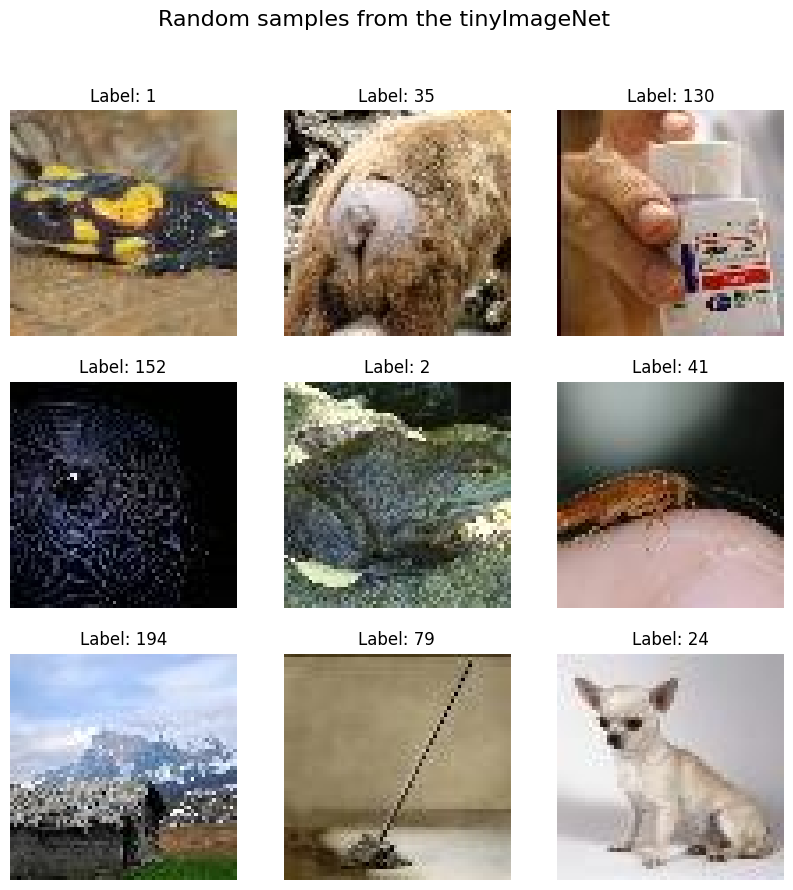

In [26]:
# plot 9 samples
idxs = np.random.randint(0, len(non_digit_dataset), 9)
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i, idx in enumerate(idxs):
    img, label = non_digit_dataset[idx]
    axs[i // 3, i % 3].imshow(img)
    axs[i // 3, i % 3].set_title(f"Label: {label}")
    axs[i // 3, i % 3].axis('off')
    plt.suptitle("Random samples from the tinyImageNet", fontsize=16)
plt.show()


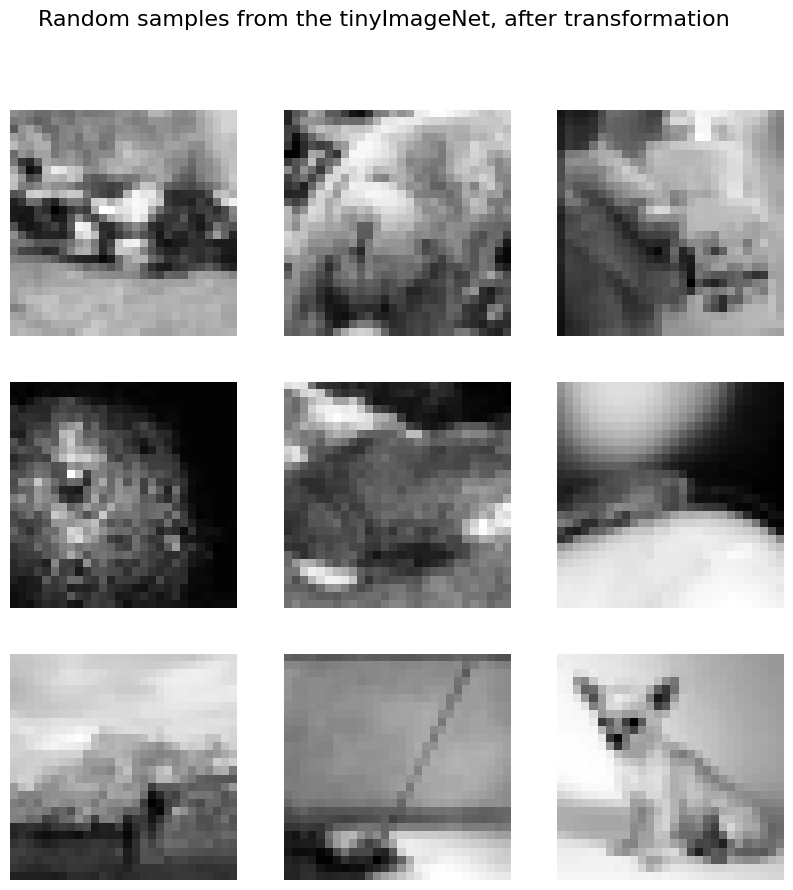

In [37]:
# plot 9 samples
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i, idx in enumerate(idxs):
    img, label = non_digit_dataset[idx]
    axs[i // 3, i % 3].imshow(img, cmap='gray')
    axs[i // 3, i % 3].axis('off')
    plt.suptitle("Random samples from the tinyImageNet, after transformation", fontsize=16)
plt.show()

In [39]:
# non didgit dataset test
non_digit_test_dataset = ImageFolder(
    root='tiny-imagenet-200/val',    # Each class is in its own subfolder
    transform=transform
)

In [40]:
base_train_dataset = datasets.MNIST(root='./data', train=True, download=True)
base_test_dataset  = datasets.MNIST(root='./data', train=False, download=True)

train_dataset = TransformedMnist(base_train_dataset, non_digit_dataset)
test_dataset  = TransformedMnist(base_test_dataset, non_digit_test_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.73MB/s]


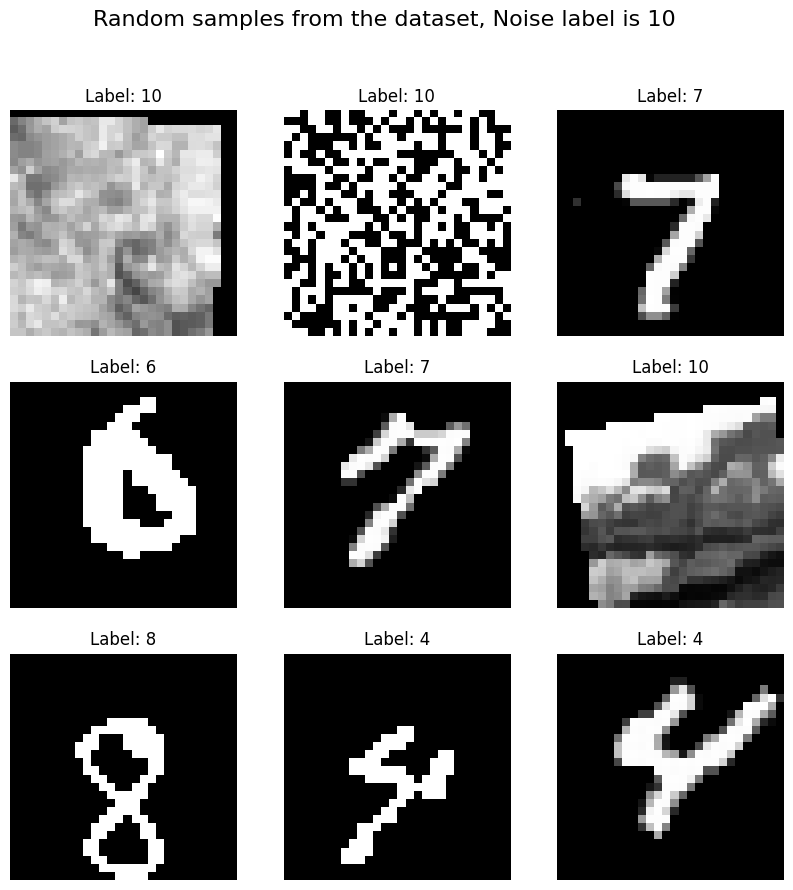

In [45]:
# plot 9 random samples
idxs = np.random.randint(0, len(train_dataset), 9)
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i, idx in enumerate(idxs):
    img, label = train_dataset[idx]
    axs[i // 3, i % 3].imshow(img.squeeze(), cmap='gray')
    axs[i // 3, i % 3].set_title(f"Label: {label}")
    axs[i // 3, i % 3].axis('off')
plt.suptitle("Random samples from the dataset, Noise label is 10", fontsize=16)
plt.show()

In [46]:
# data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [47]:
# setting up gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [48]:
# fully connected feed forward network
class Fully_Connected(nn.Module):
  def __init__(self):
    super().__init__()
    self.l1 = nn.Linear(784, 784)
    self.l2 = nn.Linear(784, 784)
    self.l3 = nn.Linear(784, 11) # one extra class for noise
    self.relu = nn.ReLU()

  def forward(self, x):
    out = self.l1(x)
    out = self.relu(out)
    out = self.l2(out)
    out = self.relu(out)
    out = self.l3(out)
    return out

In [49]:
# Hyperparameters
learning_rate = 0.001
num_epochs = 10

In [50]:
model = Fully_Connected().to(device)

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
  for batch_idx, (data, targets) in enumerate(train_loader):
    data = data.to(device)
    targets = targets.to(device)
    data = data.reshape(data.shape[0], -1)

    # forward
    output = model(data)
    loss = criterion(output, targets)

    # backward
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch_idx % 100 == 0:


      # checking the accuracy against test set
      with torch.no_grad():
        num_correct = 0
        num_samples = 0
        for batch_idx, (data, targets) in enumerate(test_loader):
          data = data.to(device)
          targets = targets.to(device)
          data = data.reshape(data.shape[0], -1)
          output = model(data)
          _, predictions = output.max(1)
          num_correct += (predictions == targets).sum()
          num_samples += predictions.size(0)

      print(f'Epoch: {epoch+1}/{num_epochs}, Batch: {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}, Accuracy: {float(num_correct)/float(num_samples)*100:.2f}')

Epoch: 1/10, Batch: 157/938, Loss: 2.4285, Accuracy: 50.23
Epoch: 1/10, Batch: 157/938, Loss: 0.5322, Accuracy: 80.99
Epoch: 1/10, Batch: 157/938, Loss: 0.3195, Accuracy: 88.65
Epoch: 1/10, Batch: 157/938, Loss: 0.2429, Accuracy: 91.28
Epoch: 1/10, Batch: 157/938, Loss: 0.2294, Accuracy: 93.02
Epoch: 1/10, Batch: 157/938, Loss: 0.1442, Accuracy: 93.68
Epoch: 1/10, Batch: 157/938, Loss: 0.1403, Accuracy: 93.89
Epoch: 1/10, Batch: 157/938, Loss: 0.2809, Accuracy: 95.28
Epoch: 1/10, Batch: 157/938, Loss: 0.1788, Accuracy: 94.87
Epoch: 1/10, Batch: 157/938, Loss: 0.2266, Accuracy: 95.00
Epoch: 2/10, Batch: 157/938, Loss: 0.1200, Accuracy: 95.69
Epoch: 2/10, Batch: 157/938, Loss: 0.1969, Accuracy: 94.97
Epoch: 2/10, Batch: 157/938, Loss: 0.1720, Accuracy: 95.52
Epoch: 2/10, Batch: 157/938, Loss: 0.0671, Accuracy: 95.28
Epoch: 2/10, Batch: 157/938, Loss: 0.3496, Accuracy: 95.86
Epoch: 2/10, Batch: 157/938, Loss: 0.2276, Accuracy: 96.07
Epoch: 2/10, Batch: 157/938, Loss: 0.0573, Accuracy: 95.

In [51]:
# save the model
torch.save(model.state_dict(), 'noisy_model.pth')